# DREAM Ablation: Soft HMM vs Viterbi on lcbench

Ablation of the HMM state-inference path in `HMM_MCMC_DREAM` on the yahpo-gym **lcbench** surrogate.

**Question:** Does soft forward-filtering (posterior-weighted proposals + Hastings acceptance) outperform hard Viterbi decoding?

| Arm | `use_soft_states` | Controller | Proposals | Acceptance |
|-----|-------------------|------------|-----------|------------|
| **Soft HMM** | `True` | `SoftBaumWelchHMMController` | Posterior-mixed weights | Soft MH + Hastings |
| **Viterbi** | `False` | `BaumWelchHMMController` | Hard discrete state | EXPLORE-greedy / standard MH |

Both arms keep `use_dream=True` and `use_baum_welch=True`. All other hyperparameters come from `best_params_hmm_mcmc_dream.json`.

> **Note (2026):** `HMM_MCMC_DREAM` is now soft-only and self-contained. The Viterbi arm is **historical** — `use_soft_states=False` is deprecated and ignored (soft mode always runs). Re-running this notebook compares archived Viterbi results against the current soft implementation.

**Protocol:** eval-count axis — every objective call at max fidelity; best-so-far `val_accuracy` vs evaluation index.


In [1]:
# =============================================================================
# Configuration
# =============================================================================
from __future__ import annotations

from pathlib import Path
import os

if Path.cwd().name == "experiments":
    REPO_ROOT = Path.cwd().parent
else:
    REPO_ROOT = Path.cwd()

SMOKE_MODE = False  # set True for a quick sanity check

LCBENCH_INSTANCES = ["3945"] if SMOKE_MODE else ["3945", "7593", "126026"]
SEEDS = [42] if SMOKE_MODE else [42, 43, 44, 45, 46]
N_EVALS = 40 if SMOKE_MODE else 150

DATA_PATH = Path(os.environ.get("YAHPO_DATA_PATH", REPO_ROOT / "yahpo_data"))
PLOTS_DIR = REPO_ROOT / "experiments" / "yahpo_ablation_plots"
RESULTS_DIR = REPO_ROOT / "experiments" / "yahpo_ablation_results"
TUNING_RESULTS_DIR = REPO_ROOT / "experiments" / "yahpo_tuning_results"
BEST_PARAMS_PATH = TUNING_RESULTS_DIR / "best_params_hmm_mcmc_dream.json"

PLOTS_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

USE_TQDM = True

LCBENCH_CFG = {
    "target": "val_accuracy",
    "fidelity": "epoch",
}

ARM_COLORS = {
    "soft": "#2ca02c",
    "viterbi": "#d62728",
}
ARM_LABELS = {
    "soft": "Soft HMM (forward filter)",
    "viterbi": "Viterbi (hard state)",
}

print(f"REPO_ROOT={REPO_ROOT}")
print(f"SMOKE_MODE={SMOKE_MODE}")
print(f"Instances={LCBENCH_INSTANCES}, seeds={SEEDS}, N_EVALS={N_EVALS}")
print(f"Total runs={2 * len(LCBENCH_INSTANCES) * len(SEEDS)}")
print(f"DATA_PATH={DATA_PATH}")
print(f"BEST_PARAMS_PATH={BEST_PARAMS_PATH}")

REPO_ROOT=c:\Users\Administrator\Documents\!prog\HPO_RL test\HPO_RL
SMOKE_MODE=False
Instances=['3945', '7593', '126026'], seeds=[42, 43, 44, 45, 46], N_EVALS=150
Total runs=30
DATA_PATH=c:\Users\Administrator\Documents\!prog\HPO_RL test\HPO_RL\yahpo_data
BEST_PARAMS_PATH=c:\Users\Administrator\Documents\!prog\HPO_RL test\HPO_RL\experiments\yahpo_tuning_results\best_params_hmm_mcmc_dream.json


In [2]:
# =============================================================================
# Dependencies + yahpo data path + ConfigSpace monkeypatch
# =============================================================================
import importlib
import subprocess
import sys

REQUIRED = [
    ("optuna", "optuna>=3.6"),
    ("optuna_integration", "optuna-integration"),
]


def _is_importable(module_name: str) -> bool:
    try:
        importlib.import_module(module_name)
        return True
    except ImportError:
        return False


missing = [spec for mod, spec in REQUIRED if not _is_importable(mod)]
if missing:
    print("Installing:", " ".join(missing))
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing, "-q"])

from yahpo_gym import local_config

local_config.init_config() if not local_config.settings_path.exists() else None
local_config.set_data_path(str(DATA_PATH))

encoding_probe = DATA_PATH / "lcbench" / "encoding.json"
if not encoding_probe.is_file():
    raise FileNotFoundError(
        f"yahpo data not found at {DATA_PATH}. "
        "Clone https://github.com/slds-lmu/yahpo_data.git"
    )
print("yahpo data OK:", encoding_probe)

yahpo data OK: c:\Users\Administrator\Documents\!prog\HPO_RL test\HPO_RL\yahpo_data\lcbench\encoding.json


In [3]:
# =============================================================================
# Imports + repo bootstrap
# =============================================================================
import json
import sys
from dataclasses import dataclass
from typing import Any

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import ConfigSpace as CS
import ConfigSpace.hyperparameters as CSH
from yahpo_gym import benchmark_set

if not hasattr(CS.ConfigurationSpace, "_sort_hyperparameters"):
    CS.ConfigurationSpace._sort_hyperparameters = lambda self: None

_root = str(REPO_ROOT)
if _root not in sys.path:
    sys.path.insert(0, _root)

from hpo_rl.baselines.HMM_MCMC_DREAM import HMM_MCMC_DREAM

plt.rcParams.update({"figure.dpi": 120, "font.size": 10})

In [4]:
# =============================================================================
# yahpo lcbench adapter helpers
# =============================================================================


@dataclass
class ScenarioContext:
    instance: str
    bench: Any
    target: str
    fidelity: str
    max_fidelity: float
    fidelity_is_int: bool
    hpo_rl_space: dict


def _hp_bounds(hp: CSH.Hyperparameter) -> tuple[float, float]:
    return float(hp.lower), float(hp.upper)


def _hp_max_constant(hp: CSH.Hyperparameter):
    if isinstance(hp, CSH.UniformIntegerHyperparameter):
        return int(hp.upper)
    return float(hp.upper)


def configspace_to_hpo_rl_space(cs: CS.ConfigurationSpace, exclude: set[str] | None = None) -> dict:
    exclude = exclude or set()
    space: dict = {}
    for hp in cs.get_hyperparameters():
        name = hp.name
        if name in exclude or isinstance(hp, CSH.Constant):
            continue
        if isinstance(hp, CSH.UniformFloatHyperparameter):
            space[name] = {
                "type": "float",
                "values": [float(hp.lower), float(hp.upper)],
                "log": bool(hp.log),
            }
        elif isinstance(hp, CSH.UniformIntegerHyperparameter):
            space[name] = {
                "type": "int",
                "values": [int(hp.lower), int(hp.upper)],
                "log": bool(hp.log),
            }
        elif isinstance(hp, CSH.CategoricalHyperparameter):
            space[name] = {"type": "categorical", "values": list(hp.choices)}
        elif isinstance(hp, CSH.OrdinalHyperparameter):
            space[name] = {"type": "categorical", "values": list(hp.sequence)}
        else:
            raise TypeError(f"Unsupported hyperparameter: {name} ({type(hp)})")
    return space


def build_lcbench_context(instance: str) -> ScenarioContext:
    bench = benchmark_set.BenchmarkSet("lcbench")
    bench.set_instance(instance)
    bench.check = False

    target = LCBENCH_CFG["target"]
    if target not in bench.targets:
        raise ValueError(f"Target {target} not in {bench.targets}")

    fidelity = LCBENCH_CFG["fidelity"]
    fspace = bench.get_fidelity_space()
    f_hp = fspace[fidelity]
    _, max_f = _hp_bounds(f_hp)
    fidelity_is_int = isinstance(f_hp, CSH.UniformIntegerHyperparameter)

    for fp in bench.config.fidelity_params:
        if fp == fidelity:
            continue
        bench.set_constant(fp, _hp_max_constant(fspace[fp]))

    opt_space = bench.get_opt_space(drop_fidelity_params=True)
    hpo_rl_space = configspace_to_hpo_rl_space(opt_space, exclude=set(bench.config.fidelity_params))

    return ScenarioContext(
        instance=instance,
        bench=bench,
        target=target,
        fidelity=fidelity,
        max_fidelity=max_f,
        fidelity_is_int=fidelity_is_int,
        hpo_rl_space=hpo_rl_space,
    )


def evaluate_at_max_fidelity(ctx: ScenarioContext, config: dict) -> float:
    cfg = dict(config)
    val = int(round(ctx.max_fidelity)) if ctx.fidelity_is_int else float(ctx.max_fidelity)
    cfg[ctx.fidelity] = val
    return float(ctx.bench.objective_function(cfg)[0][ctx.target])


contexts: dict[str, ScenarioContext] = {}
for inst in tqdm(LCBENCH_INSTANCES, desc="Building lcbench contexts", disable=not USE_TQDM):
    ctx = build_lcbench_context(inst)
    contexts[inst] = ctx
    print(
        f"  instance={inst}, target={ctx.target}, max_{ctx.fidelity}={ctx.max_fidelity}, "
        f"n_hp={len(ctx.hpo_rl_space)}"
    )

Building lcbench contexts:   0%|          | 0/3 [00:00<?, ?it/s]

  instance=3945, target=val_accuracy, max_epoch=52.0, n_hp=7
  instance=7593, target=val_accuracy, max_epoch=52.0, n_hp=7
  instance=126026, target=val_accuracy, max_epoch=52.0, n_hp=7


c:\Users\Administrator\Documents\!prog\HPO_RL test\HPO_RL\.venv\Lib\site-packages\ConfigSpace\configuration_space.py:1038: UserWarning: The field 'default' should be 'default_value' !
Found in item {'name': 'OpenML_task_id', 'choices': ['3945', '7593', '34539', '126025', '126026', '126029', '146212', '167104', '167149', '167152', '167161', '167168', '167181', '167184', '167185', '167190', '167200', '167201', '168329', '168330', '168331', '168335', '168868', '168908', '168910', '189354', '189862', '189865', '189866', '189873', '189905', '189906', '189908', '189909'], 'probabilities': None}
  return decoder(item, cs, _dec)
c:\Users\Administrator\Documents\!prog\HPO_RL test\HPO_RL\.venv\Lib\site-packages\ConfigSpace\configuration_space.py:1038: UserWarning: The field 'default' should be 'default_value' !
Found in item {'name': 'batch_size', 'log': True, 'lower': 16, 'upper': 512}
  return decoder(item, cs, _dec)
c:\Users\Administrator\Documents\!prog\HPO_RL test\HPO_RL\.venv\Lib\site-pack

In [5]:
# =============================================================================
# Load tuned params + define ablation arms
# =============================================================================

if not BEST_PARAMS_PATH.is_file():
    raise FileNotFoundError(
        f"Missing tuned params at {BEST_PARAMS_PATH}. "
        "Run experiments/yahpo_tune_hmm_lcbench.ipynb first."
    )

with open(BEST_PARAMS_PATH, "r", encoding="utf-8") as f:
    tuned_params = json.load(f)

HMM_FIXED = dict(
    n_chains=1,
    orchestrate_every=1000,
    T_min=None,
    hmm_obs_epsilon=1e-8,
    hmm_lambda_noise=0.01,
    rejection_streak=10,
)

# Base params: tuned DREAM settings, fixed ablation toggles except use_soft_states
base_params = {
    **HMM_FIXED,
    **{k: v for k, v in tuned_params.items() if k not in ("use_soft_states", "show_progress", "verbose_history")},
    "use_dream": True,
    "use_baum_welch": True,
    "show_progress": False,
    "verbose_history": False,
}

ARMS = {
    "soft": {**base_params, "use_soft_states": True},
    "viterbi": {**base_params, "use_soft_states": False},
}

print("Ablation arms (only use_soft_states differs):")
for arm_name, arm_params in ARMS.items():
    print(f"  {arm_name:8s}  use_soft_states={arm_params['use_soft_states']}")
print(f"\nShared params (sample): n_chains={base_params['n_chains']}, "
      f"p_dream={base_params['p_dream']:.3f}, bw_refit_every={base_params['bw_refit_every']}")

Ablation arms (only use_soft_states differs):
  soft      use_soft_states=True
  viterbi   use_soft_states=False

Shared params (sample): n_chains=2, p_dream=0.309, bw_refit_every=7


In [6]:
# =============================================================================
# Curve-recording runner
# =============================================================================


def run_dream_curve(
    ctx: ScenarioContext,
    hmm_params: dict,
    n_evals: int,
    seed: int,
) -> np.ndarray:
    """Run HMM_MCMC_DREAM and return best-so-far val_accuracy curve of length n_evals."""
    curve: list[float] = []
    best_acc = -np.inf

    def objective(config_dict: dict) -> float:
        nonlocal best_acc
        acc = evaluate_at_max_fidelity(ctx, config_dict)
        best_acc = max(best_acc, acc)
        curve.append(best_acc)
        return -acc

    np.random.seed(seed)
    params = dict(hmm_params)
    params.setdefault("show_progress", False)
    params.setdefault("verbose_history", False)

    alg = HMM_MCMC_DREAM(
        objective_func=objective,
        budget=n_evals,
        dict_to_optimize=ctx.hpo_rl_space,
        **params,
    )
    alg.main_loop()

    arr = np.asarray(curve, dtype=np.float64)
    if arr.size == 0:
        return np.full(n_evals, np.nan)
    if arr.size < n_evals:
        pad = np.full(n_evals - arr.size, arr[-1])
        arr = np.concatenate([arr, pad])
    return arr[:n_evals]

In [7]:
# =============================================================================
# Run ablation grid
# =============================================================================

runs = [(arm, inst, seed) for arm in ARMS for inst in LCBENCH_INSTANCES for seed in SEEDS]
raw_curves: dict[tuple[str, str, int], np.ndarray] = {}
final_bests: list[dict] = []

pbar = tqdm(runs, desc="Ablation runs", disable=not USE_TQDM)
for arm, inst, seed in pbar:
    curve = run_dream_curve(contexts[inst], ARMS[arm], N_EVALS, seed)
    raw_curves[(arm, inst, seed)] = curve
    final_bests.append(
        {
            "arm": arm,
            "instance": inst,
            "seed": seed,
            "final_best": float(curve[-1]),
        }
    )
    pbar.set_postfix(arm=arm, inst=inst, seed=seed, best=f"{curve[-1]:.4f}")

print(f"Completed {len(raw_curves)} runs.")

Ablation runs:   0%|          | 0/30 [00:00<?, ?it/s]

Completed 30 runs.


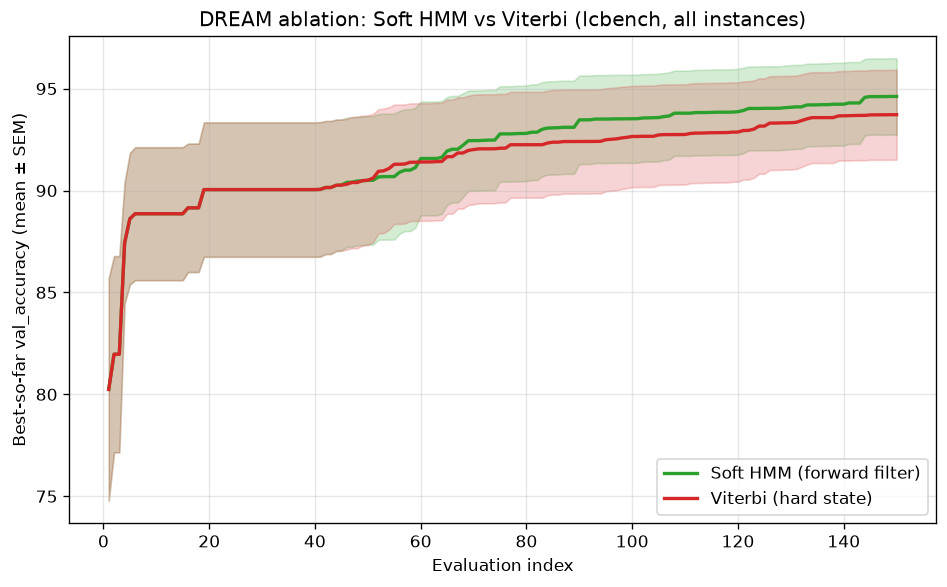

Saved c:\Users\Administrator\Documents\!prog\HPO_RL test\HPO_RL\experiments\yahpo_ablation_plots\dream_ablation_convergence_all.png


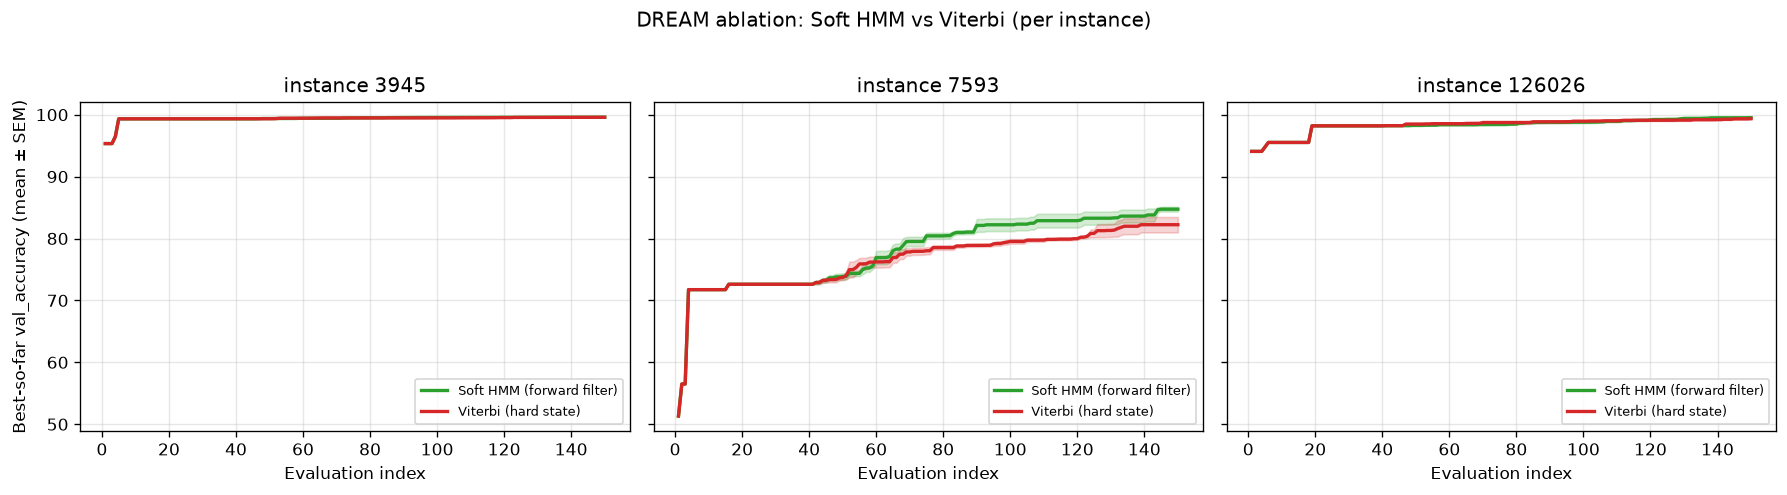

Saved c:\Users\Administrator\Documents\!prog\HPO_RL test\HPO_RL\experiments\yahpo_ablation_plots\dream_ablation_convergence_per_instance.png

=== Final best summary ===


,arm,instance,mean_final_best,std_final_best,n_runs
0,soft,all,94.6147,7.2472,15
1,soft,3945,99.5925,0.0153,5
2,soft,7593,84.7335,0.8611,5
3,soft,126026,99.5182,0.0981,5
4,viterbi,all,93.7214,8.5449,15
5,viterbi,3945,99.5801,0.0495,5
6,viterbi,7593,82.2286,2.7948,5
7,viterbi,126026,99.3555,0.2302,5



Soft minus Viterbi (overall mean final best): +0.8933


In [8]:
# =============================================================================
# Aggregate + plot
# =============================================================================

x = np.arange(1, N_EVALS + 1)


def _stack_curves(arm: str, instance: str | None = None) -> np.ndarray:
    curves = []
    for (a, inst, seed), curve in raw_curves.items():
        if a != arm:
            continue
        if instance is not None and inst != instance:
            continue
        curves.append(curve)
    return np.vstack(curves)


def _mean_sem(arr: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    mean = arr.mean(axis=0)
    sem = arr.std(axis=0, ddof=1) / np.sqrt(arr.shape[0]) if arr.shape[0] > 1 else np.zeros_like(mean)
    return mean, sem


# --- Overall convergence plot ---
fig, ax = plt.subplots(figsize=(8, 5))
for arm in ARMS:
    arr = _stack_curves(arm)
    mean, sem = _mean_sem(arr)
    color = ARM_COLORS[arm]
    label = ARM_LABELS[arm]
    ax.plot(x, mean, color=color, label=label, lw=2)
    ax.fill_between(x, mean - sem, mean + sem, color=color, alpha=0.2)

ax.set_xlabel("Evaluation index")
ax.set_ylabel("Best-so-far val_accuracy (mean ± SEM)")
ax.set_title("DREAM ablation: Soft HMM vs Viterbi (lcbench, all instances)")
ax.legend(loc="lower right")
ax.grid(True, alpha=0.3)
fig.tight_layout()
overall_path = PLOTS_DIR / "dream_ablation_convergence_all.png"
fig.savefig(overall_path, bbox_inches="tight")
plt.show()
print(f"Saved {overall_path}")

# --- Per-instance subplots ---
n_inst = len(LCBENCH_INSTANCES)
fig, axes = plt.subplots(1, n_inst, figsize=(5 * n_inst, 4), sharey=True)
if n_inst == 1:
    axes = [axes]

for ax, inst in zip(axes, LCBENCH_INSTANCES):
    for arm in ARMS:
        arr = _stack_curves(arm, instance=inst)
        mean, sem = _mean_sem(arr)
        color = ARM_COLORS[arm]
        ax.plot(x, mean, color=color, label=ARM_LABELS[arm], lw=2)
        ax.fill_between(x, mean - sem, mean + sem, color=color, alpha=0.2)
    ax.set_title(f"instance {inst}")
    ax.set_xlabel("Evaluation index")
    ax.grid(True, alpha=0.3)
    ax.legend(loc="lower right", fontsize=8)

axes[0].set_ylabel("Best-so-far val_accuracy (mean ± SEM)")
fig.suptitle("DREAM ablation: Soft HMM vs Viterbi (per instance)", y=1.02)
fig.tight_layout()
per_inst_path = PLOTS_DIR / "dream_ablation_convergence_per_instance.png"
fig.savefig(per_inst_path, bbox_inches="tight")
plt.show()
print(f"Saved {per_inst_path}")

# --- Summary table ---
df_runs = pd.DataFrame(final_bests)
summary_rows = []
for arm in ARMS:
    sub = df_runs[df_runs["arm"] == arm]
    summary_rows.append(
        {
            "arm": arm,
            "instance": "all",
            "mean_final_best": sub["final_best"].mean(),
            "std_final_best": sub["final_best"].std(ddof=1),
            "n_runs": len(sub),
        }
    )
    for inst in LCBENCH_INSTANCES:
        sub_i = sub[sub["instance"] == inst]
        summary_rows.append(
            {
                "arm": arm,
                "instance": inst,
                "mean_final_best": sub_i["final_best"].mean(),
                "std_final_best": sub_i["final_best"].std(ddof=1),
                "n_runs": len(sub_i),
            }
        )

df_summary = pd.DataFrame(summary_rows)
soft_all = df_summary[(df_summary["arm"] == "soft") & (df_summary["instance"] == "all")]["mean_final_best"].iloc[0]
vit_all = df_summary[(df_summary["arm"] == "viterbi") & (df_summary["instance"] == "all")]["mean_final_best"].iloc[0]
delta = soft_all - vit_all

print("\n=== Final best summary ===")
display(df_summary.round(4))
print(f"\nSoft minus Viterbi (overall mean final best): {delta:+.4f}")

In [9]:
# =============================================================================
# Save results
# =============================================================================

summary_path = RESULTS_DIR / "dream_ablation_summary.csv"
df_summary.to_csv(summary_path, index=False)
print(f"Saved {summary_path}")

npz_path = RESULTS_DIR / "dream_ablation_raw_curves.npz"
npz_data = {
    "x": x,
    "instances": np.array(LCBENCH_INSTANCES),
    "seeds": np.array(SEEDS),
    "arms": np.array(list(ARMS.keys())),
}
for (arm, inst, seed), curve in raw_curves.items():
    npz_data[f"curve_{arm}_{inst}_{seed}"] = curve
np.savez(npz_path, **npz_data)
print(f"Saved {npz_path}")

winner = "Soft HMM" if delta > 0 else "Viterbi" if delta < 0 else "Tie"
print(f"\nConclusion: {winner} wins overall (delta={delta:+.4f} val_accuracy).")

Saved c:\Users\Administrator\Documents\!prog\HPO_RL test\HPO_RL\experiments\yahpo_ablation_results\dream_ablation_summary.csv
Saved c:\Users\Administrator\Documents\!prog\HPO_RL test\HPO_RL\experiments\yahpo_ablation_results\dream_ablation_raw_curves.npz

Conclusion: Soft HMM wins overall (delta=+0.8933 val_accuracy).
